# Credit Card Fraud Anomaly Detection Comparsion



In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 5
DATA_PATH = '../data/creditcard.csv'

sns.set_theme(style='whitegrid')

## Load and Prepare Data

In [2]:
df = pd.read_csv(DATA_PATH)

legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

legit_train, legit_test = train_test_split(
    legit,
    test_size=0.2,
    random_state=RANDOM_STATE,
)
test_set = pd.concat([legit_test, fraud]).sample(frac=1, random_state=RANDOM_STATE)

scaler = StandardScaler()
legit_train = legit_train.copy()
test_set = test_set.copy()

legit_train[['Amount', 'Time']] = scaler.fit_transform(legit_train[['Amount', 'Time']])
test_set[['Amount', 'Time']] = scaler.transform(test_set[['Amount', 'Time']])

feature_names = legit_train.drop('Class', axis=1).columns.tolist()
X_train = legit_train.drop('Class', axis=1).values
X_test = test_set.drop('Class', axis=1).values
y_test = test_set['Class'].values

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Test fraud cases: {y_test.sum()} / {len(y_test)} ({y_test.mean():.4%})')

Training set: (227452, 30)
Test set: (57355, 30)
Test fraud cases: 492 / 57355 (0.8578%)


In [3]:
def best_f1_threshold(y_true, scores):
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    best_idx = int(np.argmax(f1_scores))
    return {
        'threshold': float(thresholds[best_idx]),
        'precision_at_threshold': float(precisions[:-1][best_idx]),
        'recall_at_threshold': float(recalls[:-1][best_idx]),
        'f1_at_threshold': float(f1_scores[best_idx]),
        'precisions': precisions,
        'recalls': recalls,
        'thresholds': thresholds,
        'best_idx': best_idx,
    }


def evaluate_scores(model_name, scores, params=None):
    threshold_info = best_f1_threshold(y_test, scores)
    threshold = threshold_info['threshold']
    y_pred = (scores >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    pr_auc = auc(threshold_info['recalls'], threshold_info['precisions'])

    mean_fraud_amount = df[df['Class'] == 1]['Amount'].mean()
    fp_cost = 10
    fn_cost = mean_fraud_amount
    model_cost = fp * fp_cost + fn * fn_cost
    baseline_cost = len(df[df['Class'] == 1]) * fn_cost

    result = {
        'model': model_name,
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'false_positive_rate': fp / (fp + tn),
        'model_cost': model_cost,
        'baseline_cost': baseline_cost,
        'cost_savings': baseline_cost - model_cost,
        'scores': scores,
        'y_pred': y_pred,
        'fpr': fpr,
        'tpr': tpr,
        **threshold_info,
    }
    if params:
        result.update(params)
    return result


def results_table(results):
    display_cols = [
        'model', 'threshold', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc',
        'false_positive_rate', 'tp', 'fp', 'fn', 'tn', 'model_cost', 'cost_savings'
    ]
    return (
        pd.DataFrame(results)[display_cols]
        .sort_values('pr_auc', ascending=False)
        .reset_index(drop=True)
    )

## Method 1: kNN

For each test transaction, the anomaly score is the average distance to its k nearest legitimate training transactions. Larger distances are treated as more anomalous.

In [4]:
def run_knn(k_values=(2, 5, 10, 20, 50)):
    tuning_rows = []
    best = None

    for k in k_values:
        knn = NearestNeighbors(n_neighbors=k, n_jobs=-1)
        knn.fit(X_train)
        distances, _ = knn.kneighbors(X_test)
        scores = distances.mean(axis=1)
        result = evaluate_scores('kNN', scores, {'k': k})
        tuning_rows.append({
            'k': k,
            'pr_auc': result['pr_auc'],
            'roc_auc': result['roc_auc'],
            'f1': result['f1'],
            'precision': result['precision'],
            'recall': result['recall'],
            'threshold': result['threshold'],
        })

        if best is None or result['pr_auc'] > best['pr_auc']:
            best = result

    return best, pd.DataFrame(tuning_rows).sort_values('pr_auc', ascending=False)

knn_result, knn_tuning = run_knn()
knn_tuning

,k,pr_auc,roc_auc,f1,precision,recall,threshold
0,2,0.616003,0.964331,0.653768,0.655102,0.652439,6.029831
4,50,0.606617,0.961138,0.688372,0.634648,0.752033,8.753294
1,5,0.589133,0.963621,0.651546,0.661088,0.642276,6.789841
3,20,0.585331,0.961851,0.666667,0.643939,0.691057,8.022711
2,10,0.574740,0.962707,0.652087,0.638132,0.666667,7.280356


## Method 2: Mahalanobis Distance

Mahalanobis distance measures how far each transaction is from the legitimate training distribution while accounting for covariance between features.

In [5]:
def run_mahalanobis():
    mean = np.mean(X_train, axis=0)
    covariance = np.cov(X_train.T)
    precision = np.linalg.pinv(covariance)

    deviations = X_test - mean
    scores = np.sqrt(np.einsum('ij,jk,ik->i', deviations, precision, deviations))
    return evaluate_scores('Mahalanobis distance', scores)

mahalanobis_result = run_mahalanobis()
print(f"Mahalanobis PR-AUC: {mahalanobis_result['pr_auc']:.4f}")

Mahalanobis PR-AUC: 0.7163


## Method 3: Isolation Forest

Isolation Forest learns random partitioning trees on legitimate transactions. 

In [6]:
def run_isolation_forest(estimator_values=(50, 100, 200, 300)):
    tuning_rows = []
    best = None

    for n_estimators in estimator_values:
        model = IsolationForest(
            n_estimators=n_estimators,
            contamination='auto',
            random_state=42,
            n_jobs=-1,
        )
        model.fit(X_train)
        scores = -model.decision_function(X_test)
        result = evaluate_scores(
            'Isolation Forest',
            scores,
            {'n_estimators': n_estimators, 'contamination': 'auto'},
        )
        tuning_rows.append({
            'n_estimators': n_estimators,
            'pr_auc': result['pr_auc'],
            'roc_auc': result['roc_auc'],
            'f1': result['f1'],
            'precision': result['precision'],
            'recall': result['recall'],
            'threshold': result['threshold'],
        })

        if best is None or result['pr_auc'] > best['pr_auc']:
            best = result

    return best, pd.DataFrame(tuning_rows).sort_values('pr_auc', ascending=False)

isolation_result, isolation_tuning = run_isolation_forest()
isolation_tuning

,n_estimators,pr_auc,roc_auc,f1,precision,recall,threshold
1,100,0.367835,0.947528,0.437761,0.371631,0.532520,0.085375
3,300,0.358079,0.950202,0.435876,0.370899,0.528455,0.086917
2,200,0.351114,0.949021,0.423390,0.332945,0.581301,0.077436
0,50,0.293949,0.947848,0.405509,0.325153,0.538618,0.079496


## Overall Comparison

In [7]:
all_results = [knn_result, mahalanobis_result, isolation_result]
comparison = results_table(all_results)
comparison

,model,threshold,precision,recall,f1,roc_auc,pr_auc,false_positive_rate,tp,fp,fn,tn,model_cost,cost_savings
0,Mahalanobis distance,24.012383,0.717803,0.770325,0.743137,0.956441,0.716311,0.002620,379,149,113,56714,15299.879289,44828.090711
1,kNN,6.029831,0.655102,0.652439,0.653768,0.964331,0.616003,0.002972,321,169,171,56694,22588.135915,37539.834085
2,Isolation Forest,0.085375,0.371631,0.532520,0.437761,0.947528,0.367835,0.007791,262,443,230,56420,32538.603862,27589.366138


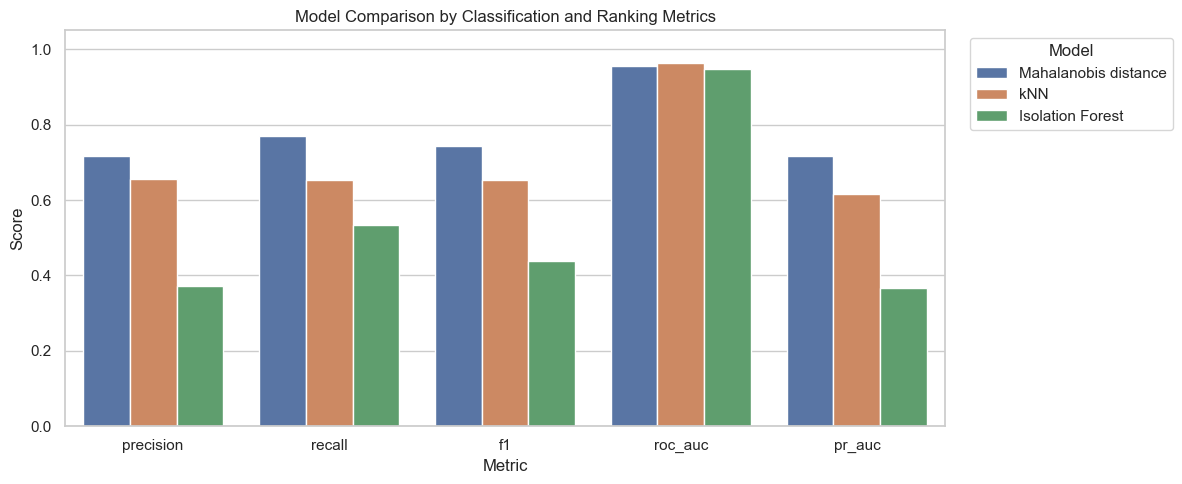

In [8]:
metric_cols = ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
plot_df = comparison.melt(id_vars='model', value_vars=metric_cols, var_name='metric', value_name='value')

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x='metric', y='value', hue='model')
plt.ylim(0, 1.05)
plt.title('Model Comparison by Classification and Ranking Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

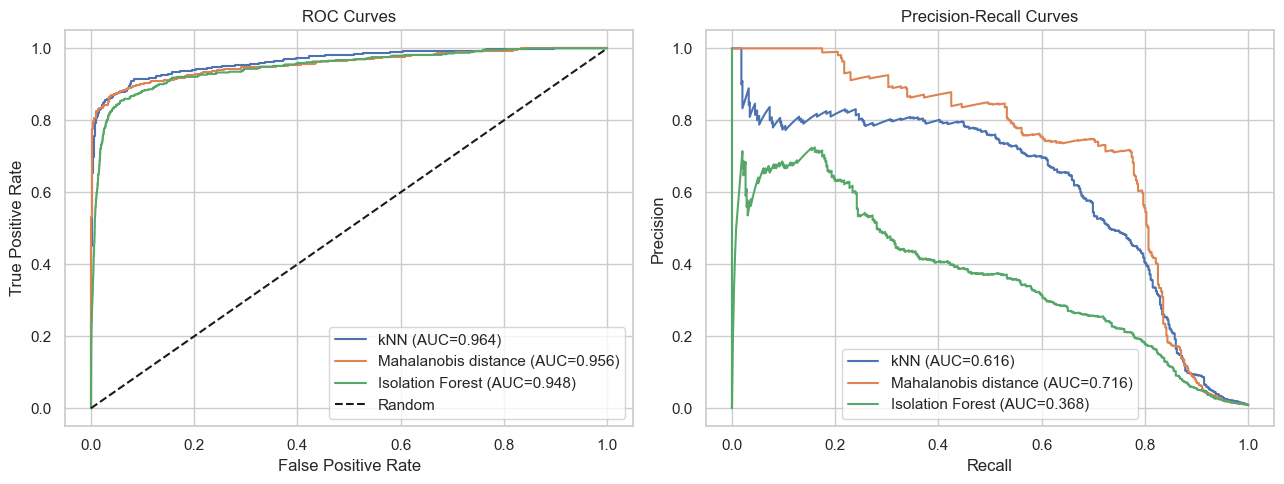

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for result in all_results:
    axes[0].plot(result['fpr'], result['tpr'], label=f"{result['model']} (AUC={result['roc_auc']:.3f})")
    axes[1].plot(result['recalls'], result['precisions'], label=f"{result['model']} (AUC={result['pr_auc']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].set_title('Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

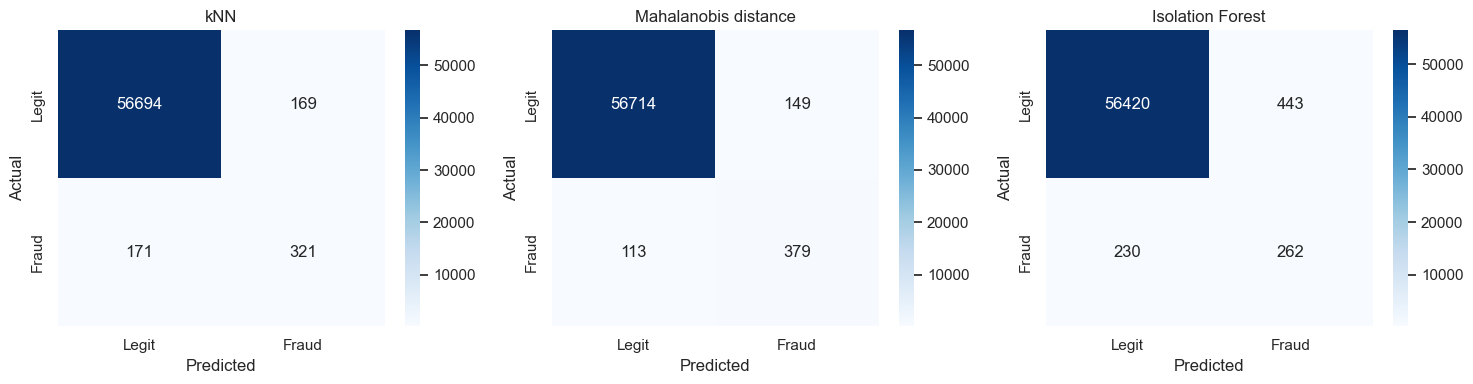

In [10]:
fig, axes = plt.subplots(1, len(all_results), figsize=(5 * len(all_results), 4))
if len(all_results) == 1:
    axes = [axes]

for ax, result in zip(axes, all_results):
    cm = np.array([[result['tn'], result['fp']], [result['fn'], result['tp']]])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Legit', 'Fraud'],
        yticklabels=['Legit', 'Fraud'],
        ax=ax,
    )
    ax.set_title(result['model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

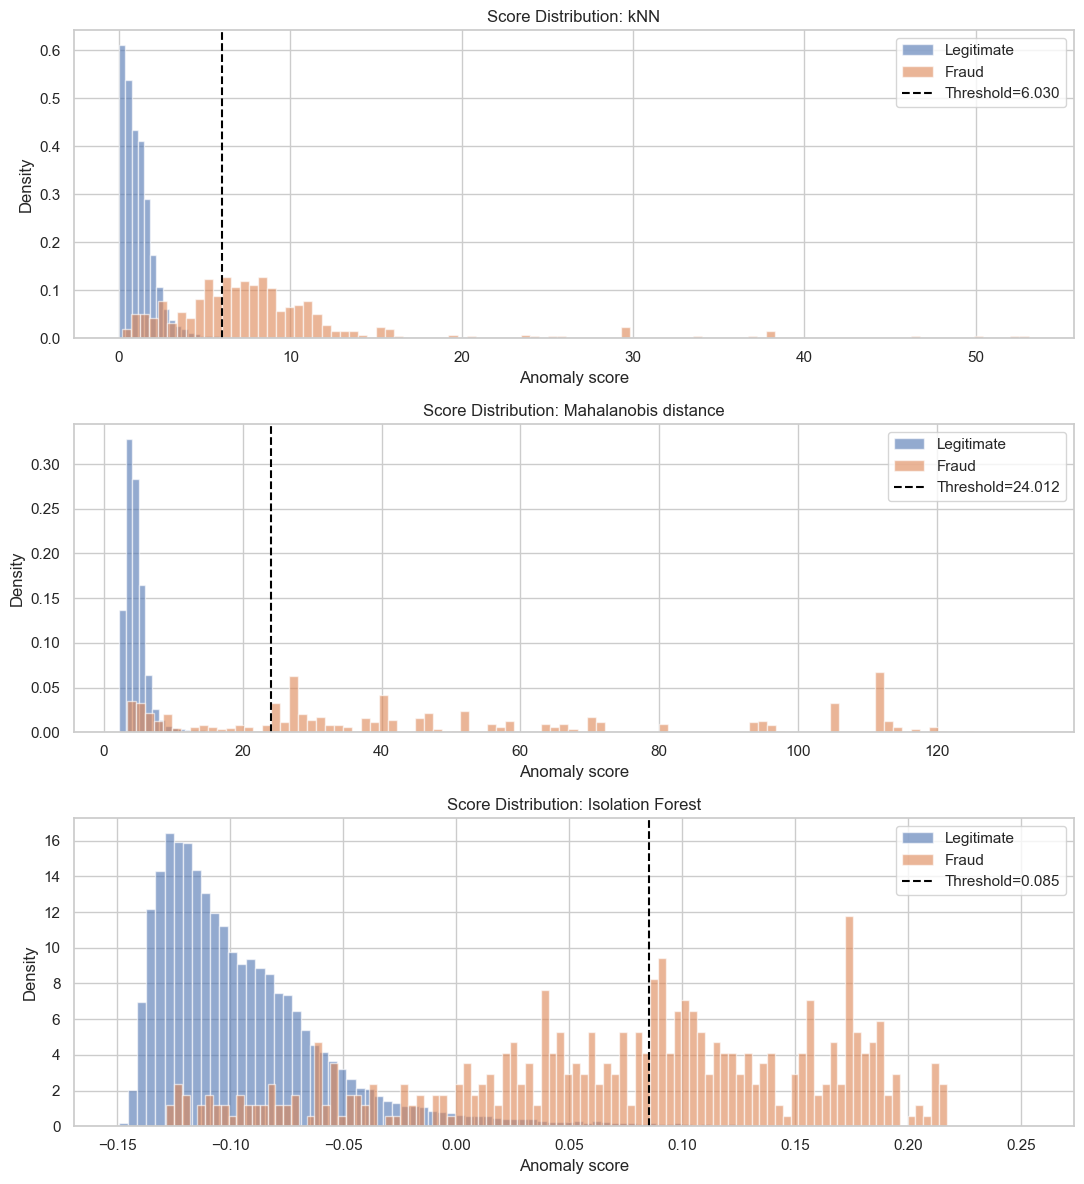

In [11]:
fig, axes = plt.subplots(len(all_results), 1, figsize=(11, 4 * len(all_results)), sharex=False)
if len(all_results) == 1:
    axes = [axes]

for ax, result in zip(axes, all_results):
    scores = result['scores']
    ax.hist(scores[y_test == 0], bins=100, alpha=0.6, label='Legitimate', density=True)
    ax.hist(scores[y_test == 1], bins=100, alpha=0.6, label='Fraud', density=True)
    ax.axvline(result['threshold'], color='black', linestyle='--', label=f"Threshold={result['threshold']:.3f}")
    ax.set_title(f"Score Distribution: {result['model']}")
    ax.set_xlabel('Anomaly score')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

## PCA

This visualization uses the best model by PR-AUC because PR-AUC is more informative than ROC-AUC for this highly imbalanced dataset.

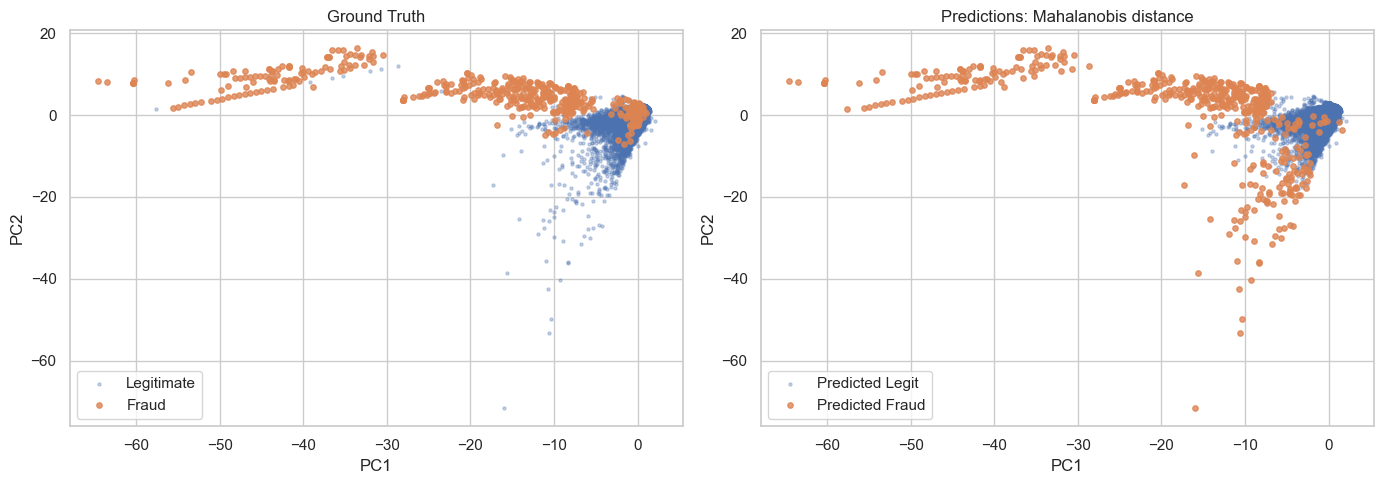

In [12]:
best_model_name = comparison.iloc[0]['model']
best_result = next(result for result in all_results if result['model'] == best_model_name)

pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_test_pca[y_test == 0, 0], X_test_pca[y_test == 0, 1], alpha=0.3, s=5, label='Legitimate')
axes[0].scatter(X_test_pca[y_test == 1, 0], X_test_pca[y_test == 1, 1], alpha=0.8, s=15, label='Fraud')
axes[0].set_title('Ground Truth')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

pred = best_result['y_pred']
axes[1].scatter(X_test_pca[pred == 0, 0], X_test_pca[pred == 0, 1], alpha=0.3, s=5, label='Predicted Legit')
axes[1].scatter(X_test_pca[pred == 1, 0], X_test_pca[pred == 1, 1], alpha=0.8, s=15, label='Predicted Fraud')
axes[1].set_title(f"Predictions: {best_model_name}")
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.show()

## Conclusion

Based on the evaluation of the three anomaly detection methods, we can draw the following conclusions:

1. Mahalanobis Distance is the best performing method. It achieved the highest Precision-Recall AUC (0.716) and F1-score (0.743). It provides the best balance between precision (0.718) and recall (0.770), resulting in the lowest model cost ($15,300) and the highest cost savings ($44,828). By accounting for the covariance between features, it effectively models the legitimate transaction distribution.

2. kNN performs moderately well. Using the average distance to the nearest neighbors, it achieved a PR-AUC of 0.616 and an F1-score of 0.654. While it has the highest ROC-AUC (0.964), its precision and recall are lower than Mahalanobis Distance, leading to lower cost savings ($37,539).

3. Isolation Forest is the least effective method. It achieved the lowest PR-AUC (0.368) and F1-score (0.438). It struggles with a high false positive rate compared to the other two methods and misses more fraud cases, leading to the highest model cost ($32,538) and lowest cost savings ($27,589).

So, Mahalanobis Distance is recommended as it provides superior detection of fraudulent transactions while minimizing false positive costs.